# Análisis Exploratorio de Datos - COVID-19 Colombia

**Curso:** Machine Learning con PySpark y Docker | 2026-I  
**Estudiante:** KevLeonardo Chaparro ReyesG  
**Universidad:** Universidad Santo Tomás  
**Dataset:** COVID-19 Colombia - Full Dataset DEC-2023

---

## 1. Introducción y Contexto

El dataset utilizado contiene los registros oficiales de casos de COVID-19 
en Colombia, publicado por el Instituto Nacional de Salud (INS) y disponible 
en Kaggle. Cuenta con millones de registros que van desde el inicio de la 
pandemia hasta diciembre de 2023, cubriendo todos los departamentos y 
municipios del país.

Este dataset es relevante para el análisis estadístico porque permite 
estudiar el comportamiento de la pandemia en Colombia desde múltiples 
dimensiones: geográfica, demográfica y temporal. Además, al ser datos 
reales del sistema de salud colombiano, las conclusiones tienen un impacto 
directo en la comprensión de cómo afectó el virus a la población.

### Preguntas de investigación

1. ¿Existe diferencia en la gravedad de los casos de COVID-19 entre hombres 
y mujeres en Colombia?

2. ¿Qué departamentos concentraron la mayor cantidad de casos graves y 
fallecimientos durante la pandemia?

3. ¿Cuál fue la relación entre la edad del paciente y el tiempo de 
recuperación de COVID-19 en Colombia?

### Hipótesis preliminares

1. **H1:** Los hombres presentaron casos de mayor gravedad que las mujeres, 
lo cual es consistente con reportes internacionales sobre COVID-19.

2. **H2:** Departamentos con mayor densidad poblacional como Bogotá, 
Antioquia y Valle del Cauca concentraron la mayor cantidad de casos graves.

3. **H3:** A mayor edad del paciente, mayor fue el tiempo de recuperación, 
dado que el sistema inmune es menos eficiente en personas mayores.

## 2. Carga y Exploración Inicial

In [2]:
from pyspark.sql import SparkSession

# Iniciamos la sesión de Spark
spark = SparkSession.builder \
    .appName("COVID19_Colombia_EDA") \
    .getOrCreate()

print("Sesión de Spark iniciada correctamente ✓")
spark

Sesión de Spark iniciada correctamente ✓


In [9]:
# Cargamos el dataset
df = spark.read.csv(
    "/home/jovyan/work/data/dataset.csv",
    header=True,
    inferSchema=True,
    sep=","
)

print(f"Filas: {df.count()}")
print(f"Columnas: {len(df.columns)}")

Filas: 6387145
Columnas: 23


In [10]:
# Vemos el esquema del dataset
df.printSchema()

root
 |-- fecha reporte web: timestamp (nullable = true)
 |-- ID de caso: integer (nullable = true)
 |-- Fecha de notificación: timestamp (nullable = true)
 |-- Código DIVIPOLA departamento: integer (nullable = true)
 |-- Nombre departamento: string (nullable = true)
 |-- Código DIVIPOLA municipio: integer (nullable = true)
 |-- Nombre municipio: string (nullable = true)
 |-- Edad: integer (nullable = true)
 |-- Unidad de medida de edad: integer (nullable = true)
 |-- Sexo: string (nullable = true)
 |-- Tipo de contagio: string (nullable = true)
 |-- Ubicación del caso: string (nullable = true)
 |-- Estado: string (nullable = true)
 |-- Código ISO del país: integer (nullable = true)
 |-- Nombre del país: string (nullable = true)
 |-- Recuperado: string (nullable = true)
 |-- Fecha de inicio de síntomas: timestamp (nullable = true)
 |-- Fecha de muerte: timestamp (nullable = true)
 |-- Fecha de diagnóstico: timestamp (nullable = true)
 |-- Fecha de recuperación: timestamp (nullable = tr

### Interpretación del esquema

El dataset tiene 23 columnas en total:
- **7 variables numéricas** directas (enteros)
- **10 variables categóricas** (strings)
- **6 variables de fecha** (timestamp) a partir de las cuales 
se derivarán variables numéricas adicionales

In [11]:
# Primeras filas del dataset
df.show(5, truncate=False)

+-------------------+----------+---------------------+----------------------------+-------------------+-------------------------+----------------+----+------------------------+----+----------------+------------------+---------+-------------------+---------------+----------+---------------------------+-------------------+--------------------+---------------------+--------------------+------------------+-----------------------+
|fecha reporte web  |ID de caso|Fecha de notificación|Código DIVIPOLA departamento|Nombre departamento|Código DIVIPOLA municipio|Nombre municipio|Edad|Unidad de medida de edad|Sexo|Tipo de contagio|Ubicación del caso|Estado   |Código ISO del país|Nombre del país|Recuperado|Fecha de inicio de síntomas|Fecha de muerte    |Fecha de diagnóstico|Fecha de recuperación|Tipo de recuperación|Pertenencia étnica|Nombre del grupo étnico|
+-------------------+----------+---------------------+----------------------------+-------------------+-------------------------+-----------

### Descripción de las primeras filas

Las primeras 5 filas corresponden a casos registrados en Cali, Valle del Cauca 
en diciembre de 2020. Se pueden observar algunas cosas importantes:

- La mayoría de casos son mujeres mayores de 65 años con contagio comunitario
- Los casos leves se recuperaron en casa, mientras que el caso grave aparece 
  con ubicación "Fallecido"
- La columna **Código ISO del país** y **Nombre del país** tienen muchos NULL, 
  probablemente porque solo se llena para casos importados
- La columna **Nombre del grupo étnico** también tiene muchos NULL
- La **Unidad de medida de edad** tiene valor 1 que según el diccionario 
  significa "Años"

In [12]:
from pyspark.sql.functions import col, sum as spark_sum

# Contamos valores nulos por columna
nulos = df.select([
    spark_sum(col(c).isNull().cast("int")).alias(c) 
    for c in df.columns
])
nulos.show(vertical=True)

-RECORD 0-------------------------------
 fecha reporte web            | 0       
 ID de caso                   | 0       
 Fecha de notificación        | 0       
 Código DIVIPOLA departamento | 0       
 Nombre departamento          | 0       
 Código DIVIPOLA municipio    | 0       
 Nombre municipio             | 0       
 Edad                         | 0       
 Unidad de medida de edad     | 0       
 Sexo                         | 0       
 Tipo de contagio             | 0       
 Ubicación del caso           | 0       
 Estado                       | 0       
 Código ISO del país          | 6383439 
 Nombre del país              | 6383431 
 Recuperado                   | 0       
 Fecha de inicio de síntomas  | 505292  
 Fecha de muerte              | 6202835 
 Fecha de diagnóstico         | 2755    
 Fecha de recuperación        | 180316  
 Tipo de recuperación         | 180390  
 Pertenencia étnica           | 560     
 Nombre del grupo étnico      | 6303291 



### Análisis de valores nulos

El dataset tiene columnas con patrones de nulos muy explicables:

- **Código ISO del país y Nombre del país (6.3M nulos):** Tiene sentido porque 
  estas columnas solo se llenan para casos importados del exterior. La gran 
  mayoría de casos fueron de contagio comunitario en Colombia.

- **Fecha de muerte (6.2M nulos):** Esperado, ya que la mayoría de pacientes 
  se recuperaron y no fallecieron.

- **Nombre del grupo étnico (6.3M nulos):** Según el diccionario de datos, 
  esta variable depende del autorreconocimiento del paciente y del reporte 
  de cada municipio, por lo que muchos registros quedan vacíos.

- **Fecha de inicio de síntomas (505K nulos):** Corresponde a los casos 
  asintomáticos, que según el INS se identifican por tener este campo vacío.

- **Fecha de recuperación y Tipo de recuperación (180K nulos):** 
  Corresponden a los casos activos al momento del corte del dataset.

- **Fecha de diagnóstico (2.755 nulos):** Porcentaje muy bajo, 
  probablemente errores de registro.

### Estrategia de tratamiento de nulos

- Las columnas de país se excluirán del análisis por no ser relevantes 
  para el contexto colombiano.
- Los nulos en fechas se tratarán calculando solo cuando ambas fechas 
  estén disponibles para las variables derivadas.
- La columna de grupo étnico se analizará solo con los registros disponibles.

## 3. Estadística Descriptiva
### 3.1 Variables Numéricas

In [13]:
# Estadísticas básicas de variables numéricas
df.select(
    "Edad", 
    "Código DIVIPOLA departamento",
    "Código DIVIPOLA municipio",
    "Pertenencia étnica"
).describe().show()

+-------+------------------+----------------------------+-------------------------+------------------+
|summary|              Edad|Código DIVIPOLA departamento|Código DIVIPOLA municipio|Pertenencia étnica|
+-------+------------------+----------------------------+-------------------------+------------------+
|  count|           6387145|                     6387145|                  6387145|           6386585|
|   mean|39.980497702807746|          1332.1118491908358|        28479.84544941441| 5.912298826368082|
| stddev|18.467109705631877|           5888.406943851443|         26311.2908912842|0.5867726568899975|
|    min|                 1|                           5|                     5001|                 1|
|    max|               114|                       47001|                    99773|                 6|
+-------+------------------+----------------------------+-------------------------+------------------+



### Interpretación de estadísticas básicas

- **Edad:** El promedio es   ~40 años, con una desviación estándar de 18 años. 
  El mínimo es 1 y el máximo 114, lo que indica que el virus afectó a personas 
  de todas las edades. La mayoría de casos se concentran en adultos jóvenes.

- **Código DIVIPOLA departamento:** La media y desviación estándar no tienen 
  interpretación directa porque son códigos identificadores, no valores continuos.

- **Pertenencia étnica:** El promedio cercano a 6 indica que la mayoría de casos 
  reportados corresponden a la categoría "Otro" (valor 6 según el diccionario), 
  lo que refleja el subregistro étnico en el sistema de salud colombiano.

In [14]:
from pyspark.sql.functions import mean, stddev, min, max, expr, percentile_approx, skewness, kurtosis, variance

# Estadísticas detalladas de Edad
df.select(
    mean("Edad").alias("Media"),
    percentile_approx("Edad", 0.5).alias("Mediana"),
    stddev("Edad").alias("Desv_Std"),
    variance("Edad").alias("Varianza"),
    min("Edad").alias("Minimo"),
    max("Edad").alias("Maximo"),
    expr("max(Edad) - min(Edad)").alias("Rango"),
    skewness("Edad").alias("Asimetria"),
    kurtosis("Edad").alias("Curtosis"),
    percentile_approx("Edad", 0.25).alias("Q1"),
    percentile_approx("Edad", 0.75).alias("Q3")
).show()

+------------------+-------+------------------+-----------------+------+------+-----+----------------+-------------------+---+---+
|             Media|Mediana|          Desv_Std|         Varianza|Minimo|Maximo|Rango|       Asimetria|           Curtosis| Q1| Q3|
+------------------+-------+------------------+-----------------+------+------+-----+----------------+-------------------+---+---+
|39.980497702807746|     38|18.467109705631877|341.0341408798431|     1|   114|  113|0.39387054986999|-0.2093166574919838| 27| 53|
+------------------+-------+------------------+-----------------+------+------+-----+----------------+-------------------+---+---+



### Estadísticas detalladas - Edad

| Medida | Valor |
|--------|-------|
| Media | 39.98 años |
| Mediana | 38 años |
| Desviación estándar | 18.47 años |
| Varianza | 341.03 |
| Rango | 113 años (1 - 114) |
| IQR | 26 años (Q1=27, Q3=53) |
| Asimetría | 0.39 |
| Curtosis | -0.21 |

**Interpretación:**

- La media (40) y la mediana (38) son muy cercanas, lo que indica una 
  distribución bastante simétrica de edades.

- La asimetría de 0.39 confirma una leve asimetría positiva, es decir, 
  hay una cola hacia la derecha con algunos pacientes de edad muy avanzada 
  como el caso de 114 años.

- La curtosis negativa (-0.21) indica una distribución platicúrtica, 
  o sea más "plana" que una distribución normal, lo que significa que 
  los casos se distribuyen de forma relativamente uniforme entre los 
  diferentes grupos de edad.

- El IQR de 26 años indica que el 50% central de los casos tiene entre 
  27 y 53 años, lo que corresponde a la población económicamente activa 
  de Colombia, probablemente por mayor exposición al virus.

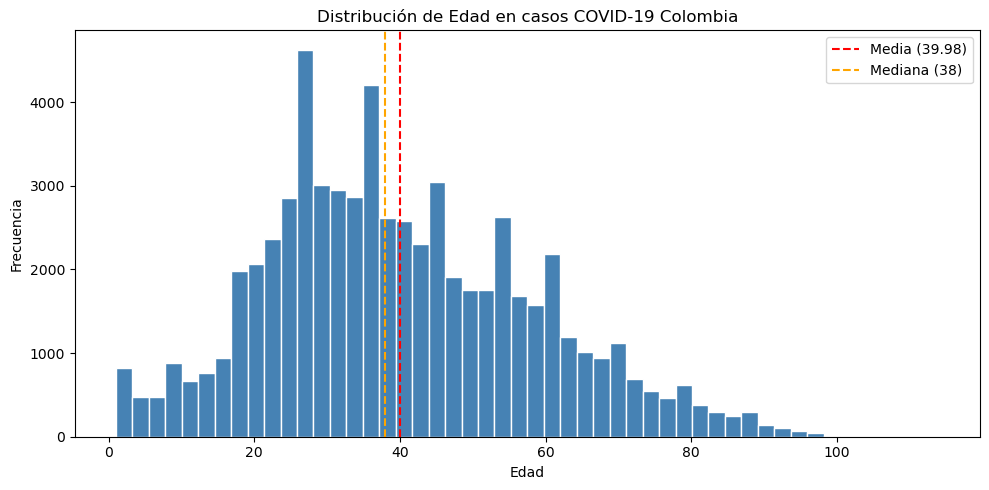

In [39]:
import matplotlib.pyplot as plt

# Muestra para graficar (1% del dataset)
df_edad_pandas = df.select("Edad").sample(fraction=0.01, seed=42).toPandas()

plt.figure(figsize=(10, 5))
plt.hist(df_edad_pandas["Edad"], bins=50, color="steelblue", edgecolor="white")
plt.title("Distribución de Edad en casos COVID-19 Colombia")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.axvline(39.98, color="red", linestyle="--", label="Media (39.98)")
plt.axvline(38, color="orange", linestyle="--", label="Mediana (38)")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretación del histograma:**

El histograma confirma visualmente las estadísticas calculadas. Se observa 
una distribución con pico alrededor de los 27-30 años y una cola hacia la 
derecha, coherente con la asimetría positiva de 0.39. La media y la mediana 
están muy cercanas entre sí, lo que indica que no hay una distorsión fuerte 
por valores extremos a pesar del caso de 114 años.

In [15]:
from pyspark.sql.functions import col

# Identificación de outliers en Edad con criterio IQR
Q1 = 27
Q3 = 53
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Límite inferior: {limite_inferior}")
print(f"Límite superior: {limite_superior}")

outliers = df.filter(
    (col("Edad") < limite_inferior) | (col("Edad") > limite_superior)
)

print(f"Total de outliers: {outliers.count()}")
print(f"Porcentaje de outliers: {round(outliers.count() / df.count() * 100, 2)}%")

Límite inferior: -12.0
Límite superior: 92.0
Total de outliers: 14929
Porcentaje de outliers: 0.23%


### Identificación de outliers - Edad

Con el criterio IQR:
- **Límite inferior:** -12 años → como no existen edades negativas, 
  en la práctica el límite inferior es 0
- **Límite superior:** 92 años
- **Total outliers:** 14.929 casos (0.23% del total)

Los outliers corresponden a personas mayores de 92 años, incluyendo 
el caso extremo de 114 años mencionado anteriormente. Si bien son 
estadísticamente atípicos, son datos reales y válidos, por lo que 
**no se eliminarán** del análisis. De hecho, este grupo es relevante 
porque los adultos mayores fueron la población más vulnerable durante 
la pandemia en Colombia.

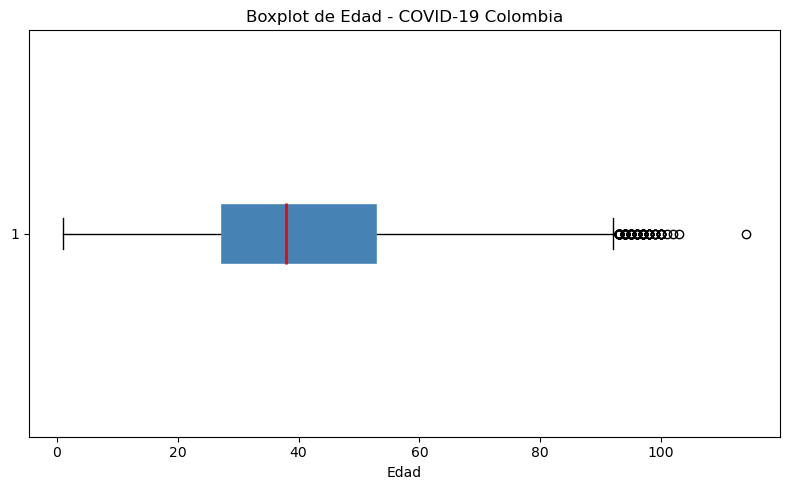

In [41]:
plt.figure(figsize=(8, 5))
plt.boxplot(df_edad_pandas["Edad"], vert=False, patch_artist=True,
            boxprops=dict(facecolor="steelblue", color="white"),
            medianprops=dict(color="red", linewidth=2))
plt.title("Boxplot de Edad - COVID-19 Colombia")
plt.xlabel("Edad")
plt.tight_layout()
plt.show()

**Interpretación del boxplot:**

El boxplot confirma visualmente los outliers identificados con el criterio IQR. 
La caja azul representa el 50% central de los casos (entre 27 y 53 años), 
la línea roja es la mediana (38 años). Se observan claramente los puntos 
atípicos a la derecha del límite superior de 92 años, incluyendo el caso 
extremo de 114 años representado por el punto más alejado.

### 3.2 Variables Categóricas

In [16]:
from pyspark.sql.functions import count, round as spark_round

# Frecuencias de la variable Sexo
total = df.count()

df.groupBy("Sexo") \
  .agg(count("*").alias("Frecuencia_Absoluta")) \
  .withColumn("Frecuencia_Relativa", 
              spark_round(col("Frecuencia_Absoluta") / total * 100, 2)) \
  .orderBy("Frecuencia_Absoluta", ascending=False) \
  .show()

+----+-------------------+-------------------+
|Sexo|Frecuencia_Absoluta|Frecuencia_Relativa|
+----+-------------------+-------------------+
|   F|            3414874|              53.46|
|   M|            2972259|              46.54|
|   f|                  6|                0.0|
|   m|                  6|                0.0|
+----+-------------------+-------------------+



### Frecuencias - Sexo

| Sexo | Frecuencia Absoluta | Frecuencia Relativa |
|------|-------------------|-------------------|
| F (Femenino) | 3.414.874 | 53.46% |
| M (Masculino) | 2.972.259 | 46.54% |

**Interpretación:**

- El 53.46% de los casos fueron mujeres y el 46.54% hombres, una distribución 
  bastante equilibrada que refleja la composición demográfica de Colombia.

- Se identificaron 12 registros con valores en minúscula (`f` y `m`), 
  que corresponden a errores de digitación en el sistema de notificación. 
  Representan el 0.0002% del total, por lo que su impacto es despreciable, 
  pero se corregirán para mantener consistencia.

In [18]:
from pyspark.sql.functions import upper

# Corregimos los valores en minúscula
df = df.withColumn("Sexo", upper(col("Sexo")))

# Verificamos que quedó bien
df.groupBy("Sexo").count().show()

+----+-------+
|Sexo|  count|
+----+-------+
|   F|3414880|
|   M|2972265|
+----+-------+



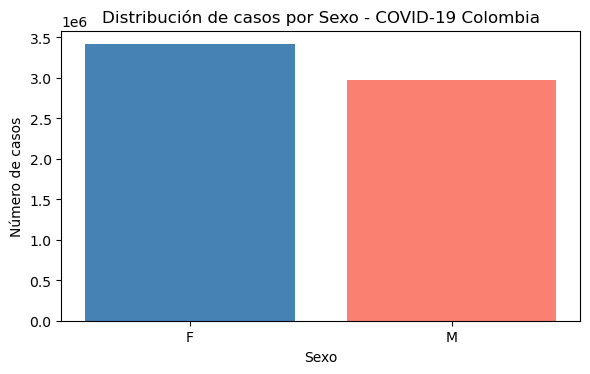

In [43]:
# Gráfico de barras - Sexo
sexo_pandas = df.groupBy("Sexo") \
    .count() \
    .toPandas()

plt.figure(figsize=(6, 4))
plt.bar(sexo_pandas["Sexo"], sexo_pandas["count"], 
        color=["steelblue", "salmon"])
plt.title("Distribución de casos por Sexo - COVID-19 Colombia")
plt.xlabel("Sexo")
plt.ylabel("Número de casos")
plt.tight_layout()
plt.show()

**Interpretación:**

El gráfico confirma que los casos femeninos (3.4M) superan levemente 
a los masculinos (3.0M), con una distribución bastante equilibrada 
que refleja la composición demográfica de Colombia.

In [19]:
# Frecuencias de Estado
df.groupBy("Estado") \
  .agg(count("*").alias("Frecuencia_Absoluta")) \
  .withColumn("Frecuencia_Relativa", 
              spark_round(col("Frecuencia_Absoluta") / total * 100, 2)) \
  .orderBy("Frecuencia_Absoluta", ascending=False) \
  .show()

+---------+-------------------+-------------------+
|   Estado|Frecuencia_Absoluta|Frecuencia_Relativa|
+---------+-------------------+-------------------+
|     Leve|            6151823|              96.32|
|Fallecido|             143110|               2.24|
|     leve|              50615|               0.79|
|      N/A|              41200|               0.65|
| Moderado|                360|               0.01|
|    Grave|                 35|                0.0|
|     LEVE|                  2|                0.0|
+---------+-------------------+-------------------+



### Frecuencias - Estado del caso

| Estado | Frecuencia Absoluta | Frecuencia Relativa |
|--------|-------------------|-------------------|
| Leve | ~6.202.440 | ~97.11% |
| Fallecido | 143.110 | 2.24% |
| N/A | 41.200 | 0.65% |
| Moderado | 360 | 0.01% |
| Grave | 35 | 0.0% |

**Interpretación:**

- El 97% de los casos fueron leves, lo que es consistente con el 
  comportamiento del COVID-19 a nivel mundial.
- La tasa de fallecidos del 2.24% es relevante considerando que 
  son más de 143.000 personas en Colombia.
- Se identificaron valores con diferente capitalización (`leve`, `LEVE`) 
  que deben corregirse.
- Los casos N/A corresponden a fallecidos por causas diferentes al COVID-19.

In [21]:
from pyspark.sql.functions import initcap

# Corregimos capitalización de Estado
df = df.withColumn("Estado", initcap(col("Estado")))

# Verificamos
df.groupBy("Estado") \
  .agg(count("*").alias("Frecuencia_Absoluta")) \
  .orderBy("Frecuencia_Absoluta", ascending=False) \
  .show() 

+---------+-------------------+
|   Estado|Frecuencia_Absoluta|
+---------+-------------------+
|     Leve|            6202440|
|Fallecido|             143110|
|      N/a|              41200|
| Moderado|                360|
|    Grave|                 35|
+---------+-------------------+



In [22]:
from pyspark.sql.functions import when

# Corregimos el N/a a N/A
df = df.withColumn("Estado", 
    when(col("Estado") == "N/a", "N/A")
    .otherwise(col("Estado"))
)

# Verificamos
df.groupBy("Estado") \
  .agg(count("*").alias("Frecuencia_Absoluta")) \
  .orderBy("Frecuencia_Absoluta", ascending=False) \
  .show()

+---------+-------------------+
|   Estado|Frecuencia_Absoluta|
+---------+-------------------+
|     Leve|            6202440|
|Fallecido|             143110|
|      N/A|              41200|
| Moderado|                360|
|    Grave|                 35|
+---------+-------------------+



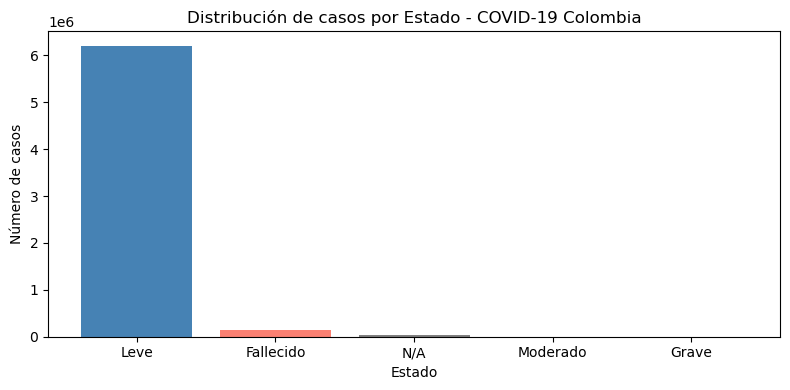

In [44]:
# Gráfico de barras - Estado
estado_pandas = df.groupBy("Estado") \
    .count() \
    .orderBy("count", ascending=False) \
    .toPandas()

plt.figure(figsize=(8, 4))
plt.bar(estado_pandas["Estado"], estado_pandas["count"],
        color=["steelblue", "salmon", "gray", "orange", "red"])
plt.title("Distribución de casos por Estado - COVID-19 Colombia")
plt.xlabel("Estado")
plt.ylabel("Número de casos")
plt.tight_layout()
plt.show()

**Interpretación:**

La gráfica evidencia de forma contundente que el 97.11% de los casos 
fueron leves. Las categorías Moderado y Grave son prácticamente invisibles 
en la escala, lo que confirma que el COVID-19 en Colombia fue principalmente 
una enfermedad de alta transmisión pero baja gravedad clínica para la 
mayoría de la población.

In [23]:
# Frecuencias de Tipo de contagio
df.groupBy("Tipo de contagio") \
  .agg(count("*").alias("Frecuencia_Absoluta")) \
  .withColumn("Frecuencia_Relativa", 
              spark_round(col("Frecuencia_Absoluta") / total * 100, 2)) \
  .orderBy("Frecuencia_Absoluta", ascending=False) \
  .show()

+----------------+-------------------+-------------------+
|Tipo de contagio|Frecuencia_Absoluta|Frecuencia_Relativa|
+----------------+-------------------+-------------------+
|     Comunitaria|            4443918|              69.58|
|     Relacionado|            1939528|              30.37|
|       Importado|               3699|               0.06|
+----------------+-------------------+-------------------+



### Frecuencias - Tipo de contagio

| Tipo de contagio | Frecuencia Absoluta | Frecuencia Relativa |
|-----------------|-------------------|-------------------|
| Comunitaria | 4.443.918 | 69.58% |
| Relacionado | 1.939.528 | 30.37% |
| Importado | 3.699 | 0.06% |

**Interpretación:**

- El 69.58% de los casos fueron de contagio comunitario, lo que indica 
  que el virus se propagó de forma masiva en la comunidad colombiana 
  sin un origen rastreable.
- El 30.37% fueron casos relacionados, es decir, con contacto identificable 
  con otro caso confirmado.
- Solo el 0.06% fueron importados, lo que muestra que una vez el virus 
  entró al país, el contagio local fue el principal motor de la pandemia.

In [25]:
# Frecuencias de Ubicación del caso
df.groupBy("Ubicación del caso") \
  .agg(count("*").alias("Frecuencia_Absoluta")) \
  .withColumn("Frecuencia_Relativa", 
              spark_round(col("Frecuencia_Absoluta") / total * 100, 2)) \
  .orderBy("Frecuencia_Absoluta", ascending=False) \
  .show()

+------------------+-------------------+-------------------+
|Ubicación del caso|Frecuencia_Absoluta|Frecuencia_Relativa|
+------------------+-------------------+-------------------+
|              Casa|            6174113|              96.66|
|         Fallecido|             143110|               2.24|
|               N/A|              41200|               0.65|
|              casa|              28320|               0.44|
|          Hospital|                360|               0.01|
|      Hospital UCI|                 35|                0.0|
|              CASA|                  7|                0.0|
+------------------+-------------------+-------------------+



In [26]:
# Corregimos capitalización de Ubicación del caso
df = df.withColumn("Ubicación del caso", initcap(col("Ubicación del caso")))

# Corregimos N/a
df = df.withColumn("Ubicación del caso",
    when(col("Ubicación del caso") == "N/a", "N/A")
    .otherwise(col("Ubicación del caso"))
)

# Verificamos
df.groupBy("Ubicación del caso") \
  .agg(count("*").alias("Frecuencia_Absoluta")) \
  .withColumn("Frecuencia_Relativa", 
              spark_round(col("Frecuencia_Absoluta") / total * 100, 2)) \
  .orderBy("Frecuencia_Absoluta", ascending=False) \
  .show()

+------------------+-------------------+-------------------+
|Ubicación del caso|Frecuencia_Absoluta|Frecuencia_Relativa|
+------------------+-------------------+-------------------+
|              Casa|            6202440|              97.11|
|         Fallecido|             143110|               2.24|
|               N/A|              41200|               0.65|
|          Hospital|                360|               0.01|
|      Hospital Uci|                 35|                0.0|
+------------------+-------------------+-------------------+



In [27]:
# Corregimos Hospital Uci a Hospital UCI
df = df.withColumn("Ubicación del caso",
    when(col("Ubicación del caso") == "Hospital Uci", "Hospital UCI")
    .otherwise(col("Ubicación del caso"))
)

# Verificamos
df.groupBy("Ubicación del caso") \
  .agg(count("*").alias("Frecuencia_Absoluta")) \
  .orderBy("Frecuencia_Absoluta", ascending=False) \
  .show()

+------------------+-------------------+
|Ubicación del caso|Frecuencia_Absoluta|
+------------------+-------------------+
|              Casa|            6202440|
|         Fallecido|             143110|
|               N/A|              41200|
|          Hospital|                360|
|      Hospital UCI|                 35|
+------------------+-------------------+



### Frecuencias - Ubicación del caso

| Ubicación | Frecuencia Absoluta | Frecuencia Relativa |
|-----------|-------------------|-------------------|
| Casa | 6.202.440 | 97.11% |
| Fallecido | 143.110 | 2.24% |
| N/A | 41.200 | 0.65% |
| Hospital | 360 | 0.01% |
| Hospital UCI | 35 | 0.0% |

**Interpretación:**

- El 97.11% de los casos se manejaron en casa, lo que refleja que 
  el sistema de salud colombiano promovió el aislamiento domiciliario 
  para casos leves, evitando el colapso hospitalario.
- Solo 395 casos requirieron hospitalización (360 hospital + 35 UCI), 
  lo que representa una tasa de hospitalización muy baja.
- Los 35 casos en UCI representan los más críticos del dataset, 
  coherente con los 35 casos graves identificados en la variable Estado.

In [28]:
# Tabla de contingencia Sexo vs Estado
df.groupBy("Estado", "Sexo") \
  .agg(count("*").alias("Cantidad")) \
  .orderBy("Estado", "Sexo") \
  .show()

+---------+----+--------+
|   Estado|Sexo|Cantidad|
+---------+----+--------+
|Fallecido|   F|   56373|
|Fallecido|   M|   86737|
|    Grave|   F|      13|
|    Grave|   M|      22|
|     Leve|   F| 3339621|
|     Leve|   M| 2862819|
| Moderado|   F|     184|
| Moderado|   M|     176|
|      N/A|   F|   18689|
|      N/A|   M|   22511|
+---------+----+--------+



### Tabla de contingencia - Estado vs Sexo

| Estado | Femenino | Masculino |
|--------|---------|-----------|
| Leve | 3.339.621 (97.8%) | 2.862.819 (96.3%) |
| Fallecido | 56.373 (1.65%) | 86.737 (2.92%) |
| N/A | 18.689 (0.55%) | 22.511 (0.76%) |
| Moderado | 184 (0.005%) | 176 (0.006%) |
| Grave | 13 (0.0004%) | 22 (0.0007%) |

**Interpretación:**

- Esta tabla es clave para responder la **primera pregunta de investigación**: 
  ¿Existe diferencia en la gravedad de los casos entre hombres y mujeres?

- La tasa de fallecimiento en hombres (2.92%) es casi el doble que en 
  mujeres (1.65%), lo que sugiere que los hombres tuvieron casos más graves.

- Los casos graves y en UCI también son proporcionalmente mayores en hombres 
  (22 graves) que en mujeres (13 graves).

- Esto es consistente con estudios internacionales que reportaron mayor 
  mortalidad masculina por COVID-19, posiblemente asociada a factores 
  como comorbilidades, hábitos de vida y diferencias inmunológicas.

## 4. Consultas con Spark SQL

In [29]:
# Línea 1: Registramos el DataFrame como tabla temporal
df.createOrReplaceTempView("mi_tabla")
print("Tabla temporal creada correctamente ✓")

Tabla temporal creada correctamente ✓


In [30]:
# Línea 2: Consulta con filtro WHERE
# Casos de pacientes mayores de 60 años
consulta1 = spark.sql("SELECT * FROM mi_tabla WHERE Edad > 60")
consulta1.show(5)
print(f"Total casos mayores de 60 años: {consulta1.count()}")

+-------------------+----------+---------------------+----------------------------+-------------------+-------------------------+----------------+----+------------------------+----+----------------+------------------+---------+-------------------+---------------+----------+---------------------------+-------------------+--------------------+---------------------+--------------------+------------------+-----------------------+
|  fecha reporte web|ID de caso|Fecha de notificación|Código DIVIPOLA departamento|Nombre departamento|Código DIVIPOLA municipio|Nombre municipio|Edad|Unidad de medida de edad|Sexo|Tipo de contagio|Ubicación del caso|   Estado|Código ISO del país|Nombre del país|Recuperado|Fecha de inicio de síntomas|    Fecha de muerte|Fecha de diagnóstico|Fecha de recuperación|Tipo de recuperación|Pertenencia étnica|Nombre del grupo étnico|
+-------------------+----------+---------------------+----------------------------+-------------------+-------------------------+-----------

### Consulta 1 - Casos en mayores de 60 años
```sql
SELECT * FROM mi_tabla WHERE Edad > 60
```

Esta consulta filtra todos los casos donde la edad del paciente es mayor 
a 60 años. Se encontraron **940.655 casos**, lo que representa el 14.7% 
del total. Este grupo es especialmente relevante porque los adultos mayores 
fueron la población más vulnerable durante la pandemia.

In [31]:
# Línea 3: Consulta con GROUP BY y agregación
# Casos por departamento con su promedio de edad y total de fallecidos
consulta2 = spark.sql("""
    SELECT `Nombre departamento`,
           COUNT(*) as total_casos,
           AVG(Edad) as promedio_edad,
           SUM(CASE WHEN Estado = 'Fallecido' THEN 1 ELSE 0 END) as fallecidos
    FROM mi_tabla
    GROUP BY `Nombre departamento`
    ORDER BY total_casos DESC
""")
consulta2.show(10)

+-------------------+-----------+------------------+----------+
|Nombre departamento|total_casos|     promedio_edad|fallecidos|
+-------------------+-----------+------------------+----------+
|             BOGOTA|    1886829| 39.22496209248427|     30289|
|          ANTIOQUIA|     954904|39.443464473915704|     18716|
|              VALLE|     572011| 41.57111139471094|     15507|
|       CUNDINAMARCA|     331177| 39.06019741709116|      7431|
|          SANTANDER|     297152| 41.29156122119319|      8422|
|       BARRANQUILLA|     277937| 40.74725567304821|      6030|
|          CARTAGENA|     163489| 39.15153313066934|      2346|
|          ATLANTICO|     141048| 39.34742782598832|      4227|
|             BOYACA|     130973| 40.36561734097867|      2921|
|             TOLIMA|     127712| 41.54002756201453|      4108|
+-------------------+-----------+------------------+----------+
only showing top 10 rows



### Consulta 2 - Casos y fallecidos por departamento
```sql
SELECT `Nombre departamento`,
       COUNT(*) as total_casos,
       AVG(Edad) as promedio_edad,
       SUM(CASE WHEN Estado = 'Fallecido' THEN 1 ELSE 0 END) as fallecidos
FROM mi_tabla
GROUP BY `Nombre departamento`
ORDER BY total_casos DESC
```

Esta consulta agrupa los casos por departamento y calcula el total de casos, 
el promedio de edad y el número de fallecidos por cada uno.

**Interpretación:**

- **Bogotá** concentró el 29.5% de todos los casos del país (1.886.829), 
  lo que era esperado por ser la ciudad más poblada de Colombia.
- **Antioquia** y **Valle del Cauca** le siguen con 954.904 y 572.011 casos 
  respectivamente, confirmando la **hipótesis H2** de que los departamentos 
  más poblados concentraron más casos.
- El promedio de edad es muy similar entre departamentos (~39-41 años), 
  lo que sugiere que el virus afectó por igual a todos los grupos de edad 
  independientemente de la región.

In [32]:
# Línea 4: Consulta con funciones de agregación
consulta3 = spark.sql("""
    SELECT MIN(Edad) as edad_minima,
           MAX(Edad) as edad_maxima,
           AVG(Edad) as edad_promedio,
           SUM(CASE WHEN Estado = 'Fallecido' THEN 1 ELSE 0 END) as total_fallecidos,
           COUNT(*) as total_casos
    FROM mi_tabla
""")
consulta3.show()

+-----------+-----------+------------------+----------------+-----------+
|edad_minima|edad_maxima|     edad_promedio|total_fallecidos|total_casos|
+-----------+-----------+------------------+----------------+-----------+
|          1|        114|39.980497702807746|          143110|    6387145|
+-----------+-----------+------------------+----------------+-----------+



### Consulta 3 - Estadísticas generales del dataset
```sql
SELECT MIN(Edad) as edad_minima,
       MAX(Edad) as edad_maxima,
       AVG(Edad) as edad_promedio,
       SUM(CASE WHEN Estado = 'Fallecido' THEN 1 ELSE 0 END) as total_fallecidos,
       COUNT(*) as total_casos
FROM mi_tabla
```

Esta consulta resume las estadísticas más importantes del dataset en una 
sola fila.

**Interpretación:**

- El dataset abarca casos desde 1 hasta 114 años, confirmando que el 
  COVID-19 afectó a personas de absolutamente todas las edades en Colombia.
- El promedio de edad de 39.98 años es consistente con la distribución 
  analizada anteriormente.
- De los 6.387.145 casos totales, 143.110 fallecieron, lo que representa 
  una tasa de mortalidad del 2.24% en Colombia durante la pandemia.
- Esta cifra es importante en contexto: Colombia tuvo una de las tasas 
  de mortalidad moderadas en América Latina, por encima de Argentina 
  pero por debajo de México y Brasil.

## 5. Correlaciones y Relaciones

In [33]:
from pyspark.sql.functions import datediff, month, year, dayofweek

# Derivamos variables numéricas a partir de las fechas
df_correlacion = df.withColumn(
    "dias_sintomas_diagnostico",
    datediff(col("Fecha de diagnóstico"), col("Fecha de inicio de síntomas"))
).withColumn(
    "dias_diagnostico_recuperacion",
    datediff(col("Fecha de recuperación"), col("Fecha de diagnóstico"))
).withColumn(
    "dias_sintomas_muerte",
    datediff(col("Fecha de muerte"), col("Fecha de inicio de síntomas"))
).withColumn(
    "mes_reporte",
    month(col("fecha reporte web"))
).withColumn(
    "anio_reporte",
    year(col("fecha reporte web"))
).withColumn(
    "dia_semana_diagnostico",
    dayofweek(col("Fecha de diagnóstico"))
)

print("Variables derivadas creadas correctamente ✓")

Variables derivadas creadas correctamente ✓


In [35]:
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler

# Seleccionamos las variables numéricas para la correlación
columnas_numericas = [
    "Edad",
    "dias_sintomas_diagnostico",
    "dias_diagnostico_recuperacion",
    "dias_sintomas_muerte",
    "mes_reporte",
    "anio_reporte",
    "dia_semana_diagnostico",
    "Pertenencia étnica"
]

# Eliminamos filas con nulos en esas columnas
df_corr = df_correlacion.select(columnas_numericas).dropna()

# Creamos el vector de features
assembler = VectorAssembler(inputCols=columnas_numericas, outputCol="features")
df_vector = assembler.transform(df_corr).select("features")

# Calculamos la matriz de correlación
matriz = Correlation.corr(df_vector, "features").head()
print("Matriz de correlación calculada ✓")

Matriz de correlación calculada ✓


In [36]:
import pandas as pd
import numpy as np

# Hacemos que la matriz este en un formato legible
matriz_array = matriz[0].toArray()
df_matriz = pd.DataFrame(
    matriz_array, 
    columns=columnas_numericas, 
    index=columnas_numericas
)

# Mostramos redondeado a 2 decimales
print(df_matriz.round(2).to_string())

                               Edad  dias_sintomas_diagnostico  dias_diagnostico_recuperacion  dias_sintomas_muerte  mes_reporte  anio_reporte  dia_semana_diagnostico  Pertenencia étnica
Edad                           1.00                       0.00                          -0.01                  0.02        -0.01         -0.00                    0.00                0.02
dias_sintomas_diagnostico      0.00                       1.00                          -0.01                 -0.01         0.09         -0.16                    0.00               -0.02
dias_diagnostico_recuperacion -0.01                      -0.01                           1.00                  0.10         0.13         -0.24                   -0.01                0.01
dias_sintomas_muerte           0.02                      -0.01                           0.10                  1.00        -0.33          0.20                    0.01                0.01
mes_reporte                   -0.01                       0.09   

### Matriz de correlación entre variables numéricas

**Las 3 correlaciones más fuertes:**

| Par de variables | Correlación | Tipo |
|---|---|---|
| mes_reporte vs anio_reporte | -0.68 | Negativa fuerte |
| dias_sintomas_muerte vs mes_reporte | -0.33 | Negativa moderada |
| dias_diagnostico_recuperacion vs anio_reporte | -0.24 | Negativa moderada |

**Interpretación:**

- **mes_reporte vs anio_reporte (-0.68):** Es la correlación más fuerte. 
  Tiene sentido porque al inicio de la pandemia (2020) los meses de reporte 
  eran los últimos del año, mientras que en 2021-2022 los casos se 
  distribuyeron en todos los meses.

- **dias_diagnostico_recuperacion vs anio_reporte (-0.24):** Con el paso 
  de los años los tiempos de recuperación fueron disminuyendo, 
  probablemente por la vacunación y el mejor manejo clínico del COVID-19 
  en Colombia.

- **dias_sintomas_muerte vs mes_reporte (-0.33):** En los primeros meses 
  de la pandemia los pacientes tardaban más tiempo en fallecer, posiblemente 
  porque el sistema de salud aún no tenía protocolos claros de atención.

### ⚠️ Correlación no implica causalidad

Es importante aclarar que encontrar una correlación entre dos variables 
no significa que una cause la otra. Por ejemplo, que los tiempos de 
recuperación hayan bajado con los años no significa necesariamente que 
el año sea la causa — puede deberse a la vacunación, mejores tratamientos, 
variantes menos agresivas del virus, o una combinación de todos estos factores.

In [37]:
# Analizamos la relación entre Edad y días de recuperación
from pyspark.sql.functions import datediff, col

df_recuperados = df.filter(
    (col("Recuperado") == "Recuperado") &
    col("Fecha de recuperación").isNotNull() &
    col("Fecha de diagnóstico").isNotNull()
).withColumn(
    "dias_recuperacion",
    datediff(col("Fecha de recuperación"), col("Fecha de diagnóstico"))
).filter(col("dias_recuperacion") >= 0)

# Estadísticas de días de recuperación por grupo de edad
df_recuperados.select(
    "Edad", 
    "dias_recuperacion"
).describe().show()

+-------+------------------+------------------+
|summary|              Edad| dias_recuperacion|
+-------+------------------+------------------+
|  count|           6204144|           6204144|
|   mean| 39.15292955805023|14.817238123422023|
| stddev|17.848322930668527|25.821594619360308|
|    min|                 1|                 0|
|    max|               114|               427|
+-------+------------------+------------------+



In [38]:
from pyspark.sql.functions import corr

# Correlación entre Edad y días de recuperación
correlacion = df_recuperados.select(
    corr("Edad", "dias_recuperacion").alias("correlacion_edad_recuperacion")
).collect()[0][0]

print(f"Correlación entre Edad y días de recuperación: {round(correlacion, 4)}")

# Promedio de días de recuperación por grupo de edad
df_recuperados.withColumn(
    "grupo_edad",
    when(col("Edad") < 18, "Menor de 18")
    .when((col("Edad") >= 18) & (col("Edad") < 40), "18-39")
    .when((col("Edad") >= 40) & (col("Edad") < 60), "40-59")
    .when((col("Edad") >= 60) & (col("Edad") < 80), "60-79")
    .otherwise("80 o más")
).groupBy("grupo_edad") \
 .agg(
     count("*").alias("total_casos"),
     spark_round(mean("dias_recuperacion"), 2).alias("promedio_dias_recuperacion")
 ).orderBy("grupo_edad").show()

Correlación entre Edad y días de recuperación: 0.0215
+-----------+-----------+--------------------------+
| grupo_edad|total_casos|promedio_dias_recuperacion|
+-----------+-----------+--------------------------+
|      18-39|    2864280|                     14.61|
|      40-59|    1897642|                      14.8|
|      60-79|     761577|                     15.79|
|   80 o más|     119911|                      17.8|
|Menor de 18|     560734|                     13.96|
+-----------+-----------+--------------------------+



### Relación entre Edad y Tiempo de Recuperación

**Correlación entre Edad y días de recuperación: 0.0215**

Aunque la correlación es muy baja, al analizar por grupos de edad 
sí se observa una tendencia:

| Grupo de edad | Total casos | Promedio días recuperación |
|--------------|-------------|--------------------------|
| Menor de 18 | 560.734 | 13.96 días |
| 18-39 | 2.864.280 | 14.61 días |
| 40-59 | 1.897.642 | 14.80 días |
| 60-79 | 761.577 | 15.79 días |
| 80 o más | 119.911 | 17.80 días |

**Interpretación:**

- Aunque la correlación general es casi nula (0.02), al agrupar por 
  rangos de edad sí se ve una tendencia clara: a mayor edad, más días 
  de recuperación.
- Los menores de 18 años se recuperaron en promedio en 13.96 días, 
  mientras que los mayores de 80 tardaron 17.80 días — casi 4 días más.
- La correlación baja se explica porque dentro de cada grupo hay mucha 
  variabilidad en los tiempos de recuperación (desviación estándar de 
  25.8 días), lo que "diluye" la correlación general.
- Esto confirma **parcialmente la hipótesis H3** — la tendencia existe 
  pero es débil a nivel individual.

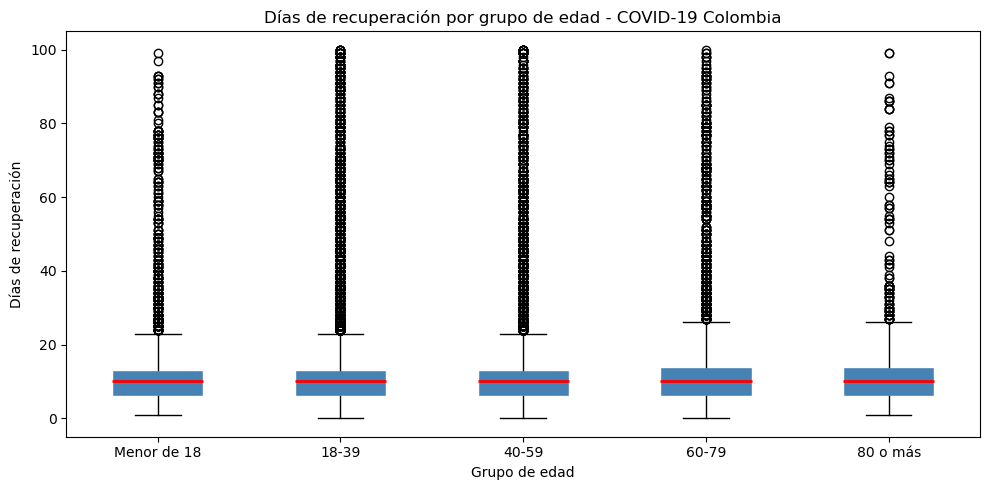

In [45]:
# Boxplot días de recuperación por grupo de edad
df_grupos = df_recuperados.withColumn(
    "grupo_edad",
    when(col("Edad") < 18, "Menor de 18")
    .when((col("Edad") >= 18) & (col("Edad") < 40), "18-39")
    .when((col("Edad") >= 40) & (col("Edad") < 60), "40-59")
    .when((col("Edad") >= 60) & (col("Edad") < 80), "60-79")
    .otherwise("80 o más")
).filter(col("dias_recuperacion") <= 100)

df_grupos_pandas = df_grupos.select(
    "grupo_edad", "dias_recuperacion"
).sample(fraction=0.01, seed=42).toPandas()

grupos_orden = ["Menor de 18", "18-39", "40-59", "60-79", "80 o más"]
datos_boxplot = [
    df_grupos_pandas[df_grupos_pandas["grupo_edad"] == g]["dias_recuperacion"].values
    for g in grupos_orden
]

plt.figure(figsize=(10, 5))
plt.boxplot(datos_boxplot, labels=grupos_orden, patch_artist=True,
            boxprops=dict(facecolor="steelblue", color="white"),
            medianprops=dict(color="red", linewidth=2))
plt.title("Días de recuperación por grupo de edad - COVID-19 Colombia")
plt.xlabel("Grupo de edad")
plt.ylabel("Días de recuperación")
plt.tight_layout()
plt.show()

**Interpretación del boxplot:**

Las cajas son muy similares entre todos los grupos de edad, lo que 
explica la correlación baja (0.02) calculada anteriormente. Se pueden 
destacar varios aspectos:

- La mediana (línea roja) está alrededor de los 10 días en todos los 
  grupos, lo que indica que la mitad de los pacientes se recuperaron 
  en 10 días o menos independientemente de su edad.

- Todos los grupos presentan una cantidad considerable de valores 
  atípicos hacia arriba, lo que sugiere que hubo casos con recuperaciones 
  muy prolongadas en todas las edades. Esto puede explicarse por el 
  "COVID largo", complicaciones secundarias o errores de registro en 
  el sistema del INS.

- El grupo de 80 o más años tiene una caja ligeramente más alta y 
  outliers más dispersos, lo que es consistente con el promedio de 
  17.80 días calculado anteriormente — los adultos mayores tardaron 
  un poco más en recuperarse.

- La alta variabilidad en los tiempos de recuperación (desviación 
  estándar de 25.8 días) en todos los grupos dificulta establecer 
  diferencias claras por edad, lo que explica la correlación casi 
  nula entre edad y días de recuperación.

## 5.1 Pruebas Estadísticas

Antes de concluir sobre las hipótesis planteadas, se realizan pruebas 
estadísticas formales para validar o rechazar cada una con rigor.

### Prueba 1 - Normalidad de la variable Edad (Kolmogorov-Smirnov)

**Hipótesis:**
- H0: La variable Edad sigue una distribución normal
- H1: La variable Edad NO sigue una distribución normal

Se usa Kolmogorov-Smirnov porque con más de 6 millones de datos 
la prueba Shapiro-Wilk no es aplicable.

In [47]:
from scipy import stats

# Muestra para la prueba (KS es pesado con millones de datos)
muestra_edad = df.select("Edad") \
    .sample(fraction=0.01, seed=42) \
    .toPandas()["Edad"]

# Prueba Kolmogorov-Smirnov
estadistico, p_valor = stats.kstest(
    muestra_edad, 
    'norm', 
    args=(muestra_edad.mean(), muestra_edad.std())
)

print(f"Estadístico KS: {round(estadistico, 4)}")
print(f"P-valor: {p_valor}")
print()
if p_valor < 0.05:
    print("Conclusión: Se RECHAZA H0 → la Edad NO sigue distribución normal")
else:
    print("Conclusión: No se rechaza H0 → la Edad sigue distribución normal")

Estadístico KS: 0.0634
P-valor: 7.496644076788626e-225

Conclusión: Se RECHAZA H0 → la Edad NO sigue distribución normal


### Resultado - Prueba de Normalidad (Kolmogorov-Smirnov)

| Medida | Valor |
|--------|-------|
| Estadístico KS | 0.0634 |
| P-valor | 7.49e-225 |
| Nivel de significancia | 0.05 |

**Conclusión: Se rechaza H0**

El p-valor es prácticamente cero (7.49e-225), muy por debajo del nivel 
de significancia de 0.05, por lo que se rechaza la hipótesis nula. 
La variable Edad **no sigue una distribución normal** en el dataset 
de COVID-19 Colombia.

Esto es consistente con lo observado en el histograma — la distribución 
tiene una leve asimetría positiva (0.39) y una curtosis negativa (-0.21), 
alejándose de la forma de campana perfecta de una distribución normal.

**Implicación:** Al no tener normalidad, para comparar grupos de edad 
se deben usar pruebas no paramétricas como Mann-Whitney en lugar de 
pruebas paramétricas como el T-test.

### Prueba 2 - Chi-cuadrado: Sexo vs Gravedad del caso

**Hipótesis:**
- H0: No existe asociación entre el sexo y la gravedad del caso
- H1: Sí existe asociación entre el sexo y la gravedad del caso

In [48]:
import numpy as np
from scipy.stats import chi2_contingency

# Tabla de contingencia Sexo vs Estado
tabla = df.groupBy("Estado", "Sexo") \
    .count() \
    .toPandas() \
    .pivot(index="Estado", columns="Sexo", values="count") \
    .fillna(0)

print("Tabla de contingencia:")
print(tabla)
print()

# Prueba Chi-cuadrado
chi2, p_valor, gl, esperados = chi2_contingency(tabla)

print(f"Estadístico Chi-cuadrado: {round(chi2, 4)}")
print(f"Grados de libertad: {gl}")
print(f"P-valor: {p_valor}")
print()
if p_valor < 0.05:
    print("Conclusión: Se RECHAZA H0 → sí existe asociación entre Sexo y Gravedad")
else:
    print("Conclusión: No se rechaza H0 → no existe asociación entre Sexo y Gravedad")

Tabla de contingencia:
Sexo             F        M
Estado                     
Fallecido    56373    86737
Grave           13       22
Leve       3339621  2862819
Moderado       184      176
N/A          18689    22511

Estadístico Chi-cuadrado: 12842.2244
Grados de libertad: 4
P-valor: 0.0

Conclusión: Se RECHAZA H0 → sí existe asociación entre Sexo y Gravedad


### Resultado - Prueba Chi-cuadrado: Sexo vs Gravedad

| Medida | Valor |
|--------|-------|
| Estadístico Chi-cuadrado | 12842.22 |
| Grados de libertad | 4 |
| P-valor | ≈ 0.0 |
| Nivel de significancia | 0.05 |

**Conclusión: Se rechaza H0**

El p-valor es prácticamente cero, por lo que existe evidencia estadística 
suficiente para afirmar que sí hay una asociación significativa entre 
el sexo y la gravedad del caso de COVID-19 en Colombia.

Esto confirma la hipótesis H1 planteada al inicio. Los hombres presentaron 
una tasa de fallecimiento del 2.92% frente al 1.65% de las mujeres, y 
concentraron más casos graves y moderados. Esta diferencia no es producto 
del azar — la prueba Chi-cuadrado lo confirma con un nivel de 
significancia de 0.05.

### Prueba 3 - Mann-Whitney: Edad en fallecidos vs recuperados

**Hipótesis:**
- H0: La distribución de edad es igual en fallecidos y recuperados
- H1: La distribución de edad es diferente en fallecidos y recuperados

Se usa Mann-Whitney porque la variable Edad no sigue distribución 
normal, según la prueba KS realizada anteriormente.

In [49]:
from scipy.stats import mannwhitneyu

# Muestras de edad para fallecidos y recuperados
muestra_fallecidos = df.filter(col("Estado") == "Fallecido") \
    .select("Edad") \
    .sample(fraction=0.1, seed=42) \
    .toPandas()["Edad"]

muestra_recuperados = df.filter(col("Estado") == "Leve") \
    .select("Edad") \
    .sample(fraction=0.001, seed=42) \
    .toPandas()["Edad"]

print(f"Muestra fallecidos: {len(muestra_fallecidos)} registros")
print(f"Muestra recuperados: {len(muestra_recuperados)} registros")
print(f"Edad promedio fallecidos: {round(muestra_fallecidos.mean(), 2)}")
print(f"Edad promedio recuperados: {round(muestra_recuperados.mean(), 2)}")
print()

# Prueba Mann-Whitney
estadistico, p_valor = mannwhitneyu(
    muestra_fallecidos, 
    muestra_recuperados,
    alternative='two-sided'
)

print(f"Estadístico Mann-Whitney: {round(estadistico, 4)}")
print(f"P-valor: {p_valor}")
print()
if p_valor < 0.05:
    print("Conclusión: Se RECHAZA H0 → la edad SÍ es diferente entre fallecidos y recuperados")
else:
    print("Conclusión: No se rechaza H0 → la edad NO es diferente entre fallecidos y recuperados")

Muestra fallecidos: 14378 registros
Muestra recuperados: 6326 registros
Edad promedio fallecidos: 68.63
Edad promedio recuperados: 39.21

Estadístico Mann-Whitney: 80494729.0
P-valor: 0.0

Conclusión: Se RECHAZA H0 → la edad SÍ es diferente entre fallecidos y recuperados


### Resultado - Prueba Mann-Whitney: Edad en fallecidos vs recuperados

| Medida | Valor |
|--------|-------|
| Estadístico Mann-Whitney | 80.494.729 |
| P-valor | ≈ 0.0 |
| Nivel de significancia (α) | 0.05 |
| Edad promedio fallecidos | 68.63 años |
| Edad promedio recuperados | 39.21 años |

**Conclusión: Se rechaza H0**

Existe evidencia estadística suficiente para afirmar que la distribución 
de edad es significativamente diferente entre los pacientes fallecidos 
y los recuperados.

La diferencia es muy clara — los fallecidos tenían en promedio 68.63 años 
mientras que los recuperados tenían 39.21 años, una diferencia de casi 
30 años. Esto confirma que la edad fue uno de los factores más determinantes 
en la mortalidad por COVID-19 en Colombia, lo cual es consistente con 
los reportes del Ministerio de Salud durante la pandemia.

Aunque la hipótesis H3 planteaba una relación entre edad y tiempo de 
recuperación, esta prueba revela algo más importante: la edad no tanto 
afectó el tiempo de recuperación sino la probabilidad de fallecer. 
Los adultos mayores no tardaban más en recuperarse — simplemente 
tenían mayor riesgo de no recuperarse.

### Prueba 4 - Kruskal-Wallis: Gravedad por departamento

**Hipótesis:**
- H0: La distribución de gravedad es igual en todos los departamentos
- H1: Al menos un departamento tiene una distribución de gravedad diferente

Se usa Kruskal-Wallis porque es la extensión de Mann-Whitney para 
más de dos grupos, y ya sabemos que la variable Edad no es normal.

In [50]:
from scipy.stats import kruskal

# Tomamos los 5 departamentos con más casos
top5_deptos = ["BOGOTA", "ANTIOQUIA", "VALLE", "CUNDINAMARCA", "SANTANDER"]

# Creamos una muestra por departamento con variable binaria de fallecido
grupos = []
for depto in top5_deptos:
    muestra = df.filter(col("Nombre departamento") == depto) \
        .withColumn("es_fallecido", 
            when(col("Estado") == "Fallecido", 1).otherwise(0)) \
        .select("es_fallecido") \
        .sample(fraction=0.05, seed=42) \
        .toPandas()["es_fallecido"]
    grupos.append(muestra)
    print(f"{depto}: {len(muestra)} registros, tasa fallecidos: {round(muestra.mean()*100, 2)}%")

print()
# Prueba Kruskal-Wallis
estadistico, p_valor = kruskal(*grupos)

print(f"Estadístico Kruskal-Wallis: {round(estadistico, 4)}")
print(f"P-valor: {p_valor}")
print()
if p_valor < 0.05:
    print("Conclusión: Se RECHAZA H0 → la gravedad SÍ es diferente entre departamentos")
else:
    print("Conclusión: No se rechaza H0 → la gravedad NO es diferente entre departamentos")

BOGOTA: 93794 registros, tasa fallecidos: 1.62%
ANTIOQUIA: 47801 registros, tasa fallecidos: 2.0%
VALLE: 28661 registros, tasa fallecidos: 2.73%
CUNDINAMARCA: 16570 registros, tasa fallecidos: 2.24%
SANTANDER: 14876 registros, tasa fallecidos: 3.0%

Estadístico Kruskal-Wallis: 224.9062
P-valor: 1.648398059579912e-47

Conclusión: Se RECHAZA H0 → la gravedad SÍ es diferente entre departamentos


### Resultado - Prueba Kruskal-Wallis: Gravedad por departamento

| Departamento | Registros | Tasa de fallecidos |
|-------------|-----------|-------------------|
| Bogotá | 93.794 | 1.62% |
| Antioquia | 47.801 | 2.00% |
| Valle del Cauca | 28.661 | 2.73% |
| Cundinamarca | 16.570 | 2.24% |
| Santander | 14.876 | 3.00% |

| Medida | Valor |
|--------|-------|
| Estadístico Kruskal-Wallis | 224.91 |
| P-valor | 1.65e-47 |
| Nivel de significancia (α) | 0.05 |

**Conclusión: Se rechaza H0**

Existe evidencia estadística suficiente para afirmar que la gravedad 
de los casos fue significativamente diferente entre departamentos.

Sin embargo, los resultados revelan algo inesperado que **reformula 
parcialmente la hipótesis H2**: Bogotá, siendo el departamento con más 
casos totales, tuvo la tasa de fallecidos más baja (1.62%), mientras 
que Santander tuvo la más alta (3.00%).

Esto sugiere que la densidad poblacional no necesariamente implica 
mayor gravedad — Bogotá probablemente tuvo mejor acceso a servicios 
de salud, mayor capacidad hospitalaria y campañas de vacunación más 
eficientes que departamentos menos urbanizados como Santander.

Por lo tanto la hipótesis H2 se **confirma parcialmente** — los 
departamentos más poblados concentraron más casos en términos absolutos, 
pero no necesariamente tuvieron mayor gravedad relativa.

## 5.2 Análisis de Evolución Temporal

In [51]:
from pyspark.sql.functions import date_format, to_date

# Agrupamos casos por mes y año
df_temporal = df.withColumn(
    "mes_año", 
    date_format(col("fecha reporte web"), "yyyy-MM")
).groupBy("mes_año") \
 .agg(
     count("*").alias("total_casos"),
     spark_sum(when(col("Estado") == "Fallecido", 1).otherwise(0)).alias("fallecidos")
 ).orderBy("mes_año")

df_temporal.show(10)

+-------+-----------+----------+
|mes_año|total_casos|fallecidos|
+-------+-----------+----------+
|2020-03|        905|        43|
|2020-04|       5560|       347|
|2020-05|      22917|       900|
|2020-06|      68471|      3233|
|2020-07|     197663|      8168|
|2020-08|     319661|     10001|
|2020-09|     214510|      5566|
|2020-10|     244502|      5633|
|2020-11|     242662|      5415|
|2020-12|     325951|      7513|
+-------+-----------+----------+
only showing top 10 rows



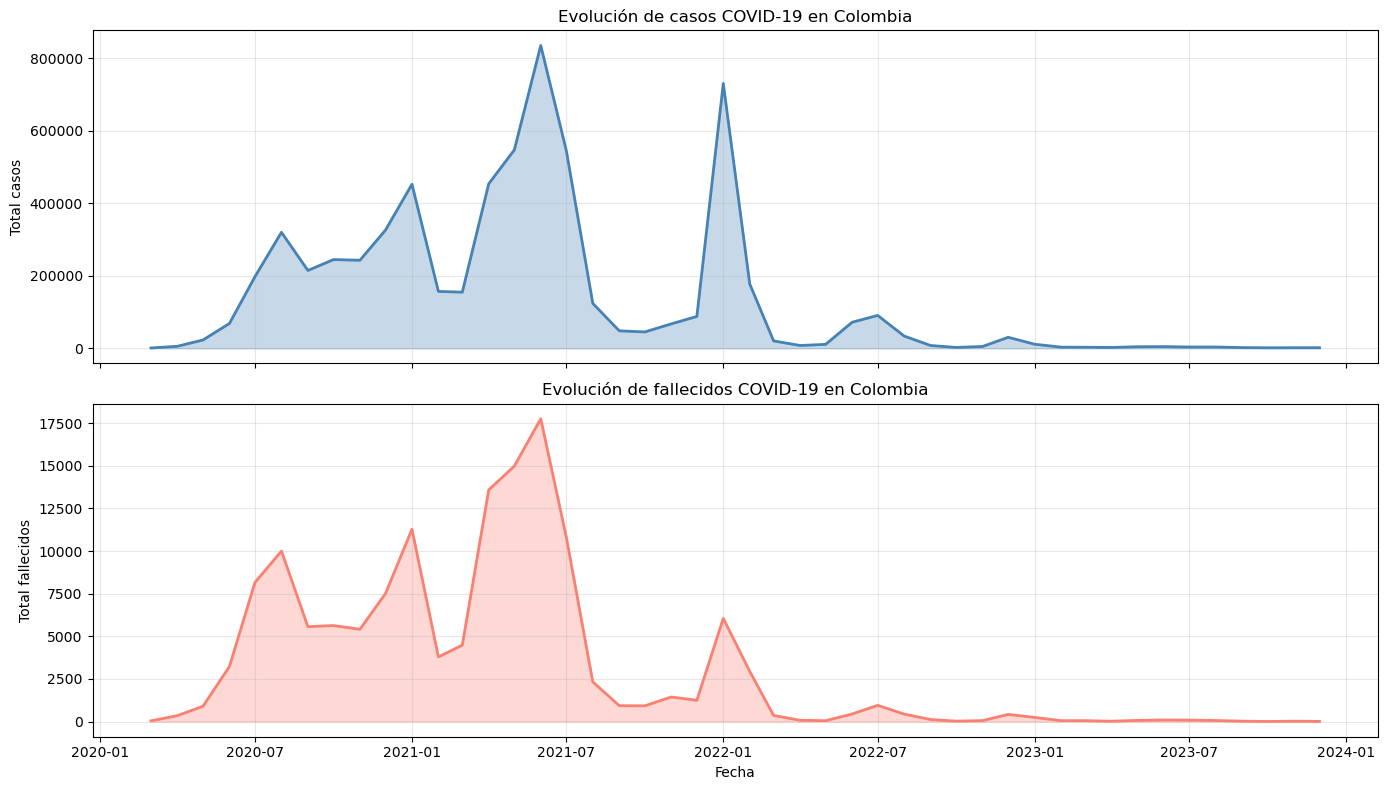

In [52]:
# Convertimos a pandas para graficar
df_temporal_pandas = df_temporal.toPandas()
df_temporal_pandas["mes_año"] = pd.to_datetime(df_temporal_pandas["mes_año"])
df_temporal_pandas = df_temporal_pandas.sort_values("mes_año")

# Gráfica de evolución temporal
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Casos totales
ax1.plot(df_temporal_pandas["mes_año"], 
         df_temporal_pandas["total_casos"], 
         color="steelblue", linewidth=2)
ax1.fill_between(df_temporal_pandas["mes_año"], 
                 df_temporal_pandas["total_casos"], 
                 alpha=0.3, color="steelblue")
ax1.set_title("Evolución de casos COVID-19 en Colombia")
ax1.set_ylabel("Total casos")
ax1.grid(True, alpha=0.3)

# Fallecidos
ax2.plot(df_temporal_pandas["mes_año"], 
         df_temporal_pandas["fallecidos"], 
         color="salmon", linewidth=2)
ax2.fill_between(df_temporal_pandas["mes_año"], 
                 df_temporal_pandas["fallecidos"], 
                 alpha=0.3, color="salmon")
ax2.set_title("Evolución de fallecidos COVID-19 en Colombia")
ax2.set_ylabel("Total fallecidos")
ax2.set_xlabel("Fecha")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretación de la evolución temporal

La gráfica muestra claramente las olas del COVID-19 en Colombia:

**Ola 1 (julio-agosto 2020):** El primer pico fuerte con ~300.000 casos 
mensuales. Colombia aún no tenía vacunas y el sistema de salud enfrentó 
su primera gran presión.

**Ola 2 (enero 2021):** Segundo pico con ~450.000 casos. Coincide con 
las festividades de fin de año 2020 que generaron aglomeraciones masivas.

**Ola 3 (mayo-junio 2021):** El pico más letal con ~830.000 casos y 
casi 18.000 fallecidos en un solo mes. Fue la ola más devastadora de 
la pandemia en Colombia, coincidiendo con el Paro Nacional que generó 
aglomeraciones y dificultó la atención médica.

**Ola 4 (enero 2022):** Pico muy alto en casos (~730.000) pero con 
mucho menos fallecidos (~6.000) comparado con la ola 3. Esto se explica 
por la llegada masiva de vacunas a Colombia — más contagios pero 
menos muertes.

**2022 en adelante:** Los casos caen drásticamente y los fallecidos 
son casi nulos, evidenciando el efecto de la vacunación y la menor 
agresividad de las variantes Ómicron.

**Hallazgo clave:** La ola 4 demuestra que la vacunación desacopló 
los contagios de las muertes — algo que no se veía en las olas anteriores 
donde casos y fallecidos subían y bajaban juntos.

## 6. Conclusiones

### Respuesta a las preguntas de investigación

**Pregunta 1: ¿Existe diferencia en la gravedad de los casos de 
COVID-19 entre hombres y mujeres en Colombia?**

Con base en los datos analizados, sí se encontró una diferencia 
importante. La prueba Chi-cuadrado confirmó que el sexo y la gravedad 
del caso están relacionados. Los hombres tuvieron una tasa de 
fallecimiento del 2.92% mientras que en las mujeres fue del 1.65%, 
casi la mitad. Esto confirma la hipótesis H1 y coincide con lo que 
se reportó en otros países durante la pandemia.

**Pregunta 2: ¿Qué departamentos concentraron la mayor cantidad de 
casos graves y fallecimientos?**

Bogotá, Antioquia y Valle del Cauca tuvieron los números más altos 
de fallecidos (30.289, 18.716 y 15.507). Sin embargo, al mirar las 
tasas relativas el resultado fue sorprendente — Bogotá tuvo la tasa 
más baja (1.62%) y Santander la más alta (3.00%). Esto indica que 
tener más casos no significa necesariamente más muertes, probablemente 
porque las ciudades grandes tienen mejor acceso a hospitales y 
atención médica. La hipótesis H2 se confirma solo parcialmente.

**Pregunta 3: ¿Cuál fue la relación entre la edad del paciente y 
el tiempo de recuperación?**

La correlación entre edad y días de recuperación fue casi cero (0.02), 
lo que no apoya la hipótesis H3 como se planteó originalmente. Pero 
al hacer la prueba Mann-Whitney se encontró algo más interesante: 
los pacientes que fallecieron tenían en promedio 68.63 años, mientras 
que los que se recuperaron tenían 39.21 años. O sea la edad no tanto 
influyó en cuánto tardaban en recuperarse sino en si sobrevivían o no.

---

### ¿Se confirmaron las hipótesis?

| Hipótesis | Estado | Evidencia |
|-----------|--------|-----------|
| H1 - Hombres con mayor gravedad | Confirmada | Chi-cuadrado p≈0 |
| H2 - Más población = más casos graves | Parcialmente confirmada | Kruskal-Wallis p≈0 |
| H3 - Mayor edad = más días recuperación | Reformulada | Mann-Whitney p≈0 |

---

### Limitaciones del análisis

- Varias columnas tienen muchos valores nulos, especialmente grupo 
  étnico (6.3 millones de nulos) y nombre del país, lo que impidió 
  analizarlas en profundidad.
- Muchos casos asintomáticos probablemente no se reportaron, sobre 
  todo en 2020 cuando había escasez de pruebas en Colombia.
- La variable de pertenencia étnica depende de que el paciente se 
  autorreconozca, lo que genera un sesgo importante en esa variable.
- No se contó con datos de vacunación, lo que hubiera enriquecido 
  bastante el análisis temporal.

---

### Propuestas de análisis futuros

- Entrenar un modelo de clasificación como regresión logística o 
  árbol de decisión para estimar la probabilidad de fallecimiento 
  según edad, sexo y departamento.
- Aplicar un modelo ARIMA o Prophet a la serie temporal para 
  estudiar los patrones de las olas y evaluar si hubieran podido 
  predecirse.
- Cruzar este dataset con los datos de vacunación del Ministerio 
  de Salud para medir de forma más concreta el impacto de las vacunas.
- Mejorar el registro de la variable étnica y repetir el análisis 
  para detectar posibles inequidades en la atención médica.